# Griffiths 1.34 & 1.35 -- Stokes' theorem and its Corollary, for a photonics/CE student

Two problems on the **fundamental theorem for curls** (Stokes' theorem)
$$\oint_{\partial S}\mathbf v\cdot d\boldsymbol\ell=\int_S(\nabla\times\mathbf v)\cdot d\mathbf a,$$
with the field $\mathbf v=xy\,\hat x+2yz\,\hat y+3zx\,\hat z$ (Problem 1.34).

- **1.34** -- test Stokes' theorem over the triangle in the $x=0$ plane with vertices $(0,0,0),(0,2,0),
  (0,0,2)$ (Fig. 1.34). We compute the surface integral **two ways (different integration orders)**, the
  line integral segment by segment, and a **Torch Monte-Carlo** cross-check.
- **1.35** -- **Corollary 1**: $\int_S(\nabla\times\mathbf v)\cdot d\mathbf a$ depends only on the boundary
  *line*, so the flux through the five open faces of a cube equals the flux through the flat cap and the
  boundary line integral. This is a direct consequence of $\nabla\cdot(\nabla\times\mathbf v)=0$.

Every result is derived and `assert`ed in **SymPy** (`init_printing`), cross-checked in **Torch**, and
tabled in **Pandas**. Runs on the Python 3.12 + Torch kernel.

*Note:* Problem 1.35 as written reuses the function and boundary of **Example 1.11**, which is not on the
provided pages. Rather than guess it, we demonstrate the corollary with the 1.34 field -- the machinery is
identical, and Ex 1.11's $\mathbf v$ drops straight into the same cells.

In [1]:
import sympy as sp
import numpy as np, torch, pandas as pd
import matplotlib.pyplot as plt
sp.init_printing()
torch.set_default_dtype(torch.float64)
x, y, z, s = sp.symbols('x y z s', real=True)
V = (x, y, z)
grad = lambda f: sp.Matrix([sp.diff(f, v) for v in V])
div  = lambda F: sum(sp.diff(F[i], V[i]) for i in range(3))
curl = lambda F: sp.Matrix([sp.diff(F[2], y) - sp.diff(F[1], z),
                            sp.diff(F[0], z) - sp.diff(F[2], x),
                            sp.diff(F[1], x) - sp.diff(F[0], y)])
print("sympy", sp.__version__, "| torch", torch.__version__, "| pandas", pd.__version__)

sympy 1.14.0 | torch 2.11.0+cu128 | pandas 2.3.3


## Problem 1.34 -- the field and its curl

$\mathbf v=xy\,\hat x+2yz\,\hat y+3zx\,\hat z$. The curl is
$\nabla\times\mathbf v=(-2y,\,-3z,\,-x)$. The triangle lies in the plane $x=0$, so the area element is
$d\mathbf a=dy\,dz\,\hat x$ and only the $x$-component of the curl, $-2y$, contributes.

In [2]:
v = sp.Matrix([x*y, 2*y*z, 3*z*x])
curl_v = curl(v)
curl_v

⎡-2⋅y⎤
⎢    ⎥
⎢-3⋅z⎥
⎢    ⎥
⎣ -x ⎦

## 1.34 surface integral -- computed two ways (different bounds of integration)

The triangle is $y,z\ge0,\ y+z\le2$. With normal $+\hat x$ the integrand is $(\nabla\times\mathbf v)_x
\big|_{x=0}=-2y$. Integrating $y$ first (limits $0\to2-z$) or $z$ first (limits $0\to2-y$) must give the
same number -- a good habit to check. Both give $-\tfrac83$.

In [3]:
integrand = curl_v[0].subs(x, 0)                       # (curl v)_x on the surface x=0  ->  -2y
S_yz = sp.integrate(sp.integrate(integrand, (y, 0, 2 - z)), (z, 0, 2))   # y first, then z
S_zy = sp.integrate(sp.integrate(integrand, (z, 0, 2 - y)), (y, 0, 2))   # z first, then y
assert S_yz == S_zy == sp.Rational(-8, 3)
print("surface integral  (y then z) =", S_yz)
print("surface integral  (z then y) =", S_zy, "   -> same answer, both = -8/3")

surface integral  (y then z) = -8/3
surface integral  (z then y) = -8/3    -> same answer, both = -8/3


## 1.34 line integral -- around the triangle boundary

Boundary $(0,0,0)\to(0,2,0)\to(0,0,2)\to(0,0,0)$ (oriented to match the $+\hat x$ normal). On $x=0$ the
field is $\mathbf v=(0,2yz,0)$, so only the hypotenuse (where both $y,z\neq0$) contributes. The loop
integral equals the surface integral -- **Stokes' theorem holds**, both $-\tfrac83$.

In [4]:
def seg_integral(P0, P1):
    r  = [P0[i] + s*(P1[i] - P0[i]) for i in range(3)]      # straight segment P0 -> P1
    vt = [v[i].subs({x: r[0], y: r[1], z: r[2]}) for i in range(3)]
    dr = [sp.diff(ri, s) for ri in r]
    return sp.integrate(sum(vt[i]*dr[i] for i in range(3)), (s, 0, 1))

segs = [((0,0,0),(0,2,0)), ((0,2,0),(0,0,2)), ((0,0,2),(0,0,0))]
contribs = [seg_integral(a, b) for a, b in segs]
line_134 = sum(contribs)
print("segment contributions:", contribs, " (only the hypotenuse is nonzero)")
print("line integral  =", line_134)
print("surface integral =", S_yz, "  -> Stokes' theorem verified:", line_134 == S_yz)
assert line_134 == S_yz == sp.Rational(-8, 3)

segment contributions: [0, -8/3, 0]  (only the hypotenuse is nonzero)
line integral  = -8/3
surface integral = -8/3   -> Stokes' theorem verified: True


## 1.34 Torch Monte-Carlo cross-check

Sample points uniformly in the triangle and average the integrand $-2y$ times the area ($\tfrac12\cdot2
\cdot2=2$). The stochastic estimate converges on the exact $-\tfrac83\approx-2.667$.

In [5]:
torch.manual_seed(0)
N = 4_000_000
pts = torch.rand(N, 2) * 2.0                              # (y, z) in the [0,2]^2 bounding square
yv, zv = pts[:, 0], pts[:, 1]
inside = (yv + zv) <= 2.0                                 # keep the triangle
area = 2.0
mc_surface = area * (-2.0*yv[inside]).mean()
print(f"Torch MC surface integral = {float(mc_surface):+.4f}   exact -8/3 = {-8/3:+.4f}")
assert abs(float(mc_surface) - (-8/3)) < 5e-3

Torch MC surface integral = -2.6678   exact -8/3 = -2.6667


## Problem 1.35 -- Corollary 1: the flux of a curl depends only on the boundary

Corollary 1 says $\int_S(\nabla\times\mathbf v)\cdot d\mathbf a$ is the same for **every** surface sharing a
boundary line. Reason: two such surfaces form a *closed* surface, and by the divergence theorem the closed-
surface flux of a curl is $\int_{\text{vol}}\nabla\cdot(\nabla\times\mathbf v)\,d\tau=0$ because
$\nabla\cdot(\nabla\times\mathbf v)=0$ (Feynman 2-7). So the flux through the **five open faces** of a cube
equals the flux through the flat cap and the boundary line integral.

We demonstrate on the unit cube with the $x=0$ face open, using the 1.34 field. All three agree at $-1$.

In [6]:
assert sp.simplify(div(curl_v)) == 0                    # div(curl v) = 0  -> corollary holds
# flat cap: x=0 face, normal +x
flat = sp.integrate(sp.integrate(curl_v[0].subs(x, 0), (y, 0, 1)), (z, 0, 1))
# five outward faces of the unit cube (open at x=0): x=1(+x), y=0(-y), y=1(+y), z=0(-z), z=1(+z)
faces = {
    "x=1 (+x)":  sp.integrate(sp.integrate(curl_v[0].subs(x, 1), (y, 0, 1)), (z, 0, 1)),
    "y=0 (-y)": -sp.integrate(sp.integrate(curl_v[1].subs(y, 0), (x, 0, 1)), (z, 0, 1)),
    "y=1 (+y)":  sp.integrate(sp.integrate(curl_v[1].subs(y, 1), (x, 0, 1)), (z, 0, 1)),
    "z=0 (-z)": -sp.integrate(sp.integrate(curl_v[2].subs(z, 0), (x, 0, 1)), (y, 0, 1)),
    "z=1 (+z)":  sp.integrate(sp.integrate(curl_v[2].subs(z, 1), (x, 0, 1)), (y, 0, 1)),
}
five_face = sum(faces.values())
rim = sum(seg_integral(a, b) for a, b in
          [((0,0,0),(0,1,0)), ((0,1,0),(0,1,1)), ((0,1,1),(0,0,1)), ((0,0,1),(0,0,0))])
for k, val in faces.items():
    print(f"  face {k}: {val}")
print(f"\nfive-face sum = {five_face}   flat cap = {flat}   rim line integral = {rim}")
print("Corollary 1 verified: all equal (y-faces cancel, z-faces cancel):",
      five_face == flat == rim == -1)
assert five_face == flat == rim == -1

  face x=1 (+x): -1
  face y=0 (-y): 3/2
  face y=1 (+y): -3/2
  face z=0 (-z): 1/2
  face z=1 (+z): -1/2

five-face sum = -1   flat cap = -1   rim line integral = -1
Corollary 1 verified: all equal (y-faces cancel, z-faces cancel): True


In [7]:
# Torch MC of the five-face sum: on each unit face (area 1), average the outward-normal
# component of curl v = (-2y, -3z, -x).  (u, w) are the two free coordinates on each face.
torch.manual_seed(1)
M = 2_000_000
u, w = torch.rand(M), torch.rand(M)
mc = {
    "x=1 (+x)": float((-2.0*u).mean()),                  # (curl)_x = -2y,  y=u
    "y=0 (-y)": float(-(-3.0*w).mean()),                 # (curl)_y = -3z,  z=w,  outward -y
    "y=1 (+y)": float((-3.0*w).mean()),
    "z=0 (-z)": float(-(-u).mean()),                     # (curl)_z = -x,   x=u,  outward -z
    "z=1 (+z)": float((-u).mean()),
}
mc_five = sum(mc.values())
print("Torch MC per face:", {k: round(v_, 3) for k, v_ in mc.items()})
print("Torch MC five-face sum =", round(mc_five, 4), "  exact = -1")
assert abs(mc_five - (-1.0)) < 5e-3

Torch MC per face: {'x=1 (+x)': -1.0, 'y=0 (-y)': 1.5, 'y=1 (+y)': -1.5, 'z=0 (-z)': 0.5, 'z=1 (+z)': -0.5}
Torch MC five-face sum = -0.9999   exact = -1


## Connecting the dots: curl, torque, and angular momentum

The curl is a **cross-product** operator, $\nabla\times\mathbf v$, and it shares its rotational meaning with
the mechanics you know: **torque** $\boldsymbol\tau=\mathbf r\times\mathbf F$ and **angular momentum**
$\mathbf L=\mathbf r\times\mathbf p$. Curl measures the *local circulation* of a field (how much a tiny
paddle-wheel spins); torque measures the tendency of a force to spin a body. Stokes' theorem then says the
total circulation on a surface equals the boundary loop integral -- the field-theory version of "net twist =
edge effect." In photonics this is Faraday's law $\nabla\times\mathbf E=-\partial_t\mathbf B$: the curl of
$\mathbf E$ drives the circulating induced field.

In [8]:
# the shared r x (.) structure, shown once in SymPy
rx, ry, rz, Fx, Fy, Fz = sp.symbols('r_x r_y r_z F_x F_y F_z')
r_vec = sp.Matrix([rx, ry, rz]); F_vec = sp.Matrix([Fx, Fy, Fz])
torque = r_vec.cross(F_vec)
print("torque  r x F ="); sp.pprint(torque)
print("curl is the same cross product with r -> nabla:  (nabla x v)")

torque  r x F =
⎡-F_y⋅r_z + F_z⋅r_y⎤
⎢                  ⎥
⎢ Fₓ⋅r_z - F_z⋅rₓ  ⎥
⎢                  ⎥
⎣ -Fₓ⋅r_y + F_y⋅rₓ ⎦
curl is the same cross product with r -> nabla:  (nabla x v)


## Pandas summary

In [9]:
rows = [
    {"quantity": "1.34 line integral",        "exact": "-8/3", "value": float(line_134)},
    {"quantity": "1.34 surface (y then z)",   "exact": "-8/3", "value": float(S_yz)},
    {"quantity": "1.34 surface (z then y)",   "exact": "-8/3", "value": float(S_zy)},
    {"quantity": "1.34 surface Torch MC",     "exact": "-8/3", "value": round(float(mc_surface), 4)},
    {"quantity": "1.35 flat cap flux",        "exact": "-1",   "value": float(flat)},
    {"quantity": "1.35 five-face flux",       "exact": "-1",   "value": float(five_face)},
    {"quantity": "1.35 five-face Torch MC",   "exact": "-1",   "value": round(mc_five, 4)},
    {"quantity": "1.35 rim line integral",    "exact": "-1",   "value": float(rim)},
]
df = pd.DataFrame(rows)
print(df.to_string(index=False))
print("\n1.34: Stokes verified (-8/3).  1.35: Corollary 1 verified (-1).")

               quantity exact     value
     1.34 line integral  -8/3 -2.666667
1.34 surface (y then z)  -8/3 -2.666667
1.34 surface (z then y)  -8/3 -2.666667
  1.34 surface Torch MC  -8/3 -2.667800
     1.35 flat cap flux    -1 -1.000000
    1.35 five-face flux    -1 -1.000000
1.35 five-face Torch MC    -1 -0.999900
 1.35 rim line integral    -1 -1.000000

1.34: Stokes verified (-8/3).  1.35: Corollary 1 verified (-1).


## Plots -- the triangle (1.34) and the open cube (1.35)

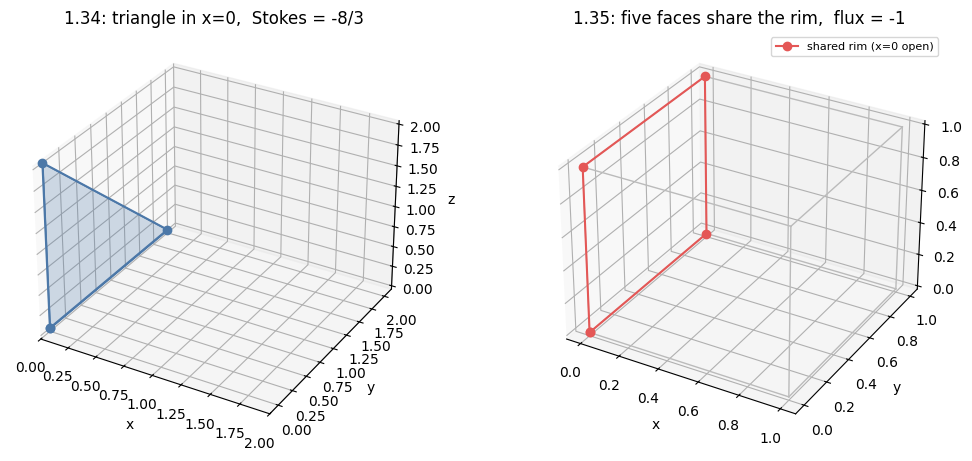

In [10]:
fig = plt.figure(figsize=(11, 4.6))
# (1) Problem 1.34 triangle in the x=0 plane
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
tri = np.array([[0,0,0],[0,2,0],[0,0,2],[0,0,0]], float)
ax1.plot(tri[:,0], tri[:,1], tri[:,2], "-o", color="#4C78A8")
ax1.add_collection3d(Poly3DCollection([[(0,0,0),(0,2,0),(0,0,2)]], color="#4C78A8", alpha=0.25))
ax1.set_title("1.34: triangle in x=0,  Stokes = -8/3")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("z"); ax1.set_xlim(0, 2)
# (2) Problem 1.35 unit cube, open at x=0 (five faces + shared rim)
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
C = np.array([[i,j,k] for i in (0,1) for j in (0,1) for k in (0,1)], float)
for a in range(8):
    for b in range(a+1, 8):
        if np.sum(np.abs(C[a]-C[b])) == 1:
            ax2.plot(*zip(C[a], C[b]), color="#bbb", lw=1)
rim = np.array([[0,0,0],[0,1,0],[0,1,1],[0,0,1],[0,0,0]], float)
ax2.plot(rim[:,0], rim[:,1], rim[:,2], "-o", color="#E45756", label="shared rim (x=0 open)")
ax2.set_title("1.35: five faces share the rim,  flux = -1")
ax2.set_xlabel("x"); ax2.set_ylabel("y"); ax2.set_zlabel("z"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

## What to write down

- **Stokes' theorem** $\oint\mathbf v\cdot d\boldsymbol\ell=\int(\nabla\times\mathbf v)\cdot d\mathbf a$.
  For 1.34, $\nabla\times\mathbf v=(-2y,-3z,-x)$; on the $x=0$ triangle only $-2y$ counts, and both sides
  give $-\tfrac83$.
- A surface integral can be done in **either order**; getting the same number is a correctness check --
  set the inner limits from the geometry ($y:0\to2-z$ or $z:0\to2-y$).
- **Corollary 1** (1.35): the curl-flux through a surface depends only on its **boundary line**, so five
  cube faces = flat cap = loop integral ($-1$ here). It follows from
  $\nabla\cdot(\nabla\times\mathbf v)=0$ -- the same identity from Feynman 2-7.
- **Curl = torque/angular-momentum structure**: all are $\mathbf r\times(\cdot)$ rotation operators; Stokes
  turns local circulation into an edge integral, exactly as Faraday's law $\nabla\times\mathbf E=-\dot{\mathbf B}$
  works in photonics.
- Problem **1.30** (last session) and **1.35's Ex 1.11 field** both need functions not yet provided -- paste
  them and they slot into these same cells.

Subject-verb-object: the curl fills the surface; the surface integral counts the circulation; the boundary
loop returns the same number; the cube's five faces cannot change it.